## index.ipynb

[![Binder Container Image](https://github.com/rcghpge/capstone/actions/workflows/binder.yml/badge.svg)](https://github.com/rcghpge/capstone/actions/workflows/binder.yml)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/rcghpge/capstone/HEAD?urlpath=lab)

### Project Overview

Project Homepage: [https://github.com/rcghpge/capstone](https://github.com/rcghpge/capstone)

This capstone project applies machine learning for infant mortality rate (IMR) prediction, serving as a data-driven and research-driven baseline for health analytics.

**Notebook Purpose**

`index.ipynb` provides exploratory analysis of regression models and the primary dataset (`Key_indicator_districtwise.csv` targeting `YY_Infant_Mortality_Rate_Imr_Total_Person`). The modular design supports extension into medicine and related fields.

---

#### Google Colaboratory (Google Colab): Save a Copy

[Introduction to Google Colaboratory Notebooks](https://colab.research.google.com/notebooks/intro.ipynb#recent=true) - Learn more about Google Colab and notebooks.

[INFO] **Warning: "This notebook was not authored by Google"** is normal (project codebase is hosted on GitHub).

To remove warning + save work:
1. **File → Save a copy in Drive** 
2. Rename: `capstone-health-analytics.ipynb`
3. **Run warning-free** from your Drive

**Why**: Makes it "yours" → no security nag. 

---

#### The Binder Project
The Binder project offers an easy place to share computing environments to everyone. It allows users to specify custom environments and share them with a single link. Use cases involve workshops, scientific workflows and streamline sharing among teams.

Learn more about The Binder Project: [https://jupyter.org/binder](https://jupyter.org/binder).

A Binder container image for a reproducible environment is provided if you face dependency or setup issues. See Environments section for research and development environment options.

---

#### Environments

| Platform | Link | Purpose |
|----------|------|---------|
| **Colab** |  [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rcghpge/capstone/blob/main/notebooks/index.ipynb) | Google Colab notebooks |
| **Binder** | [![Binder](https://mybinder.org/badge_logo.svg)](https://binder.mybinder.org/v2/gh/rcghpge/capstone/main) | Binder for portable Jupyter environments |
| **Codespaces** | [![Codespaces](https://github.com/codespaces/badge.svg)](https://github.com/codespaces/new?hide_repo_select=true&ref=main&repo=rcghpge%2Fcapstone) | GitHub Codespaces via VS Code |


---

### Git Clone

For environments that do not have the complete capstone environment (e.g., Google Colab or other development environments), You can clone the GitHub repository into your notebook utilizing the provided commands.

In [1]:
!git clone https://github.com/rcghpge/capstone.git
%cd capstone
%ls

Cloning into 'capstone'...
remote: Enumerating objects: 2035, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 2035 (delta 41), reused 39 (delta 32), pack-reused 1982 (from 2)
Receiving objects: 100% (2035/2035), 117.16 MiB | 20.39 MiB/s, done.
Resolving deltas: 100% (856/856), done.
/home/rc/Academia/capstone/notebooks/capstone
CITATION.cff  README.md    assets/  notebooks/   pyproject.toml
Dockerfile    __init__.py  binder/  pixi.lock    requirements.txt
LICENSE       app.py       models/  pylock.toml


In [1]:
%ls

artifacts/  eda/  index.ipynb  model-tests/  test/


In [2]:
!pwd

/home/rc/Academia/capstone/notebooks


In [3]:
# Tree is a command line utility to print contents of directories
#!apt-get install tree # uncomment to install if needed
!tree -L 1

.
├── artifacts
├── eda
├── index.ipynb
├── model-tests
└── test

5 directories, 1 file


In [4]:
import os

# Set file path to src/root @ capstone directory
# Skip step if on Google Colab
src = os.chdir("../")
!pwd

/home/rc/Academia/capstone


In [5]:
%ls

CITATION.cff  __init__.py  data/       out/         pyproject.toml    tools/
Dockerfile    app.py       docs/       pixi.lock    pyvenv.cfg        venv/
LICENSE       assets/      models/     prototype/   requirements.txt
README.md     binder/      notebooks/  pylock.toml  test.bak/


### Datasets

KaggleHub enables portable dataset access in Jupyter notebooks without manual downloads. Use `import kagglehub` to load resources like `Key_indicator_districtwise.csv` directly.

In [2]:
# Lets source the dataset that was utilized in this project build. 
import os
import kagglehub
import pandas as pd
import tqdm 

path = kagglehub.dataset_download("rajanand/key-indicators-of-annual-health-survey")
print(f"Kaggle Health Analytics data repository:")
print("Dataset at:", path)
print("Files:", os.listdir(path))

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
districtwise_file = next(f for f in csv_files if 'districtwise' in f.lower())
dataset = os.path.join(path, districtwise_file)

df = pd.read_csv(dataset)
print(f"\nPrimary dataset: {districtwise_file}")
print(f"✅ Dataframe shape: {df.shape} (expected ~284 rows x 642 cols for districts)") 

100%|█████████████████████████████████████████████████████████████████████████████████████| 1.34M/1.34M [02:15<00:00, 10.4kB/s]

Extracting files...


Kaggle Health Analytics data repository:
Dataset at: /home/rc/.cache/kagglehub/datasets/rajanand/key-indicators-of-annual-health-survey/versions/1
Files: ['Key_indicator_districtwise.csv', 'Key_indicator_statewise.csv', 'Key_Indicator_State_and_District_wise_data']

Primary dataset: Key_indicator_districtwise.csv
✅ Dataframe shape: (284, 644) (expected ~284 rows x 642 cols for districts)


In [3]:
# We can copy the source file path and verify where the data is and make a copy. Local research and development environment for KaggleHub dataset
# download would resolve to the .cache directory below. Other environments such as Google Colab may differ. Be sure to resolve dataset source as needed.
# Google Colab possible dataset download directory: /kaggle/input/key-indicators-of-annual-health-survey

!mkdir data

# List host cache (if mounted) or container cache
%ls ~/.cache/kagglehub/datasets/rajanand/key-indicators-of-annual-health-survey/versions/1

# Copy from container cache (post-kagglehub download) or host mount
!cp -r ~/.cache/kagglehub/datasets/rajanand/key-indicators-of-annual-health-survey/versions/1/* data/

Key_Indicator_State_and_District_wise_data/  Key_indicator_statewise.csv
Key_indicator_districtwise.csv


In [8]:
%pwd

'/home/rc/Academia/capstone'

In [9]:
# You can navigate the project's structure in Jupyter or in Bash at the command-line. Many other platforms as well e.g. IDE's Spyder/VS Code, and Google Colab as well
data = os.chdir("data")
%pwd

'/home/rc/Academia/capstone/data'

In [10]:
# Check existing datasets and data directory
%ls

Key_Indicator_State_and_District_wise_data/
Key_indicator_districtwise.csv
Key_indicator_statewise.csv
ahs_districtwise.csv
ahs_statewise.csv
ahsdistrictwise.db
ahsstatewise.db
healthanalytics.db
healthanalytics.zip*
test_outliers_summary.csv
test_outliers_summary.csv:Zone.Identifier
train_outliers_summary.csv


In [11]:
import pandas as pd
data = pd.read_csv("Key_indicator_districtwise.csv")
df = pd.DataFrame(data)
df.head()

,State_Name,State_District_Name,AA_Sample_Units_Total,AA_Sample_Units_Rural,AA_Sample_Units_Urban,AA_Households_Total,AA_Households_Rural,AA_Households_Urban,AA_Population_Total,AA_Population_Rural,...,ZZ_Under_Five_Mortality_Rate_U5MR_Rural_Lower_Limit,ZZ_Under_Five_Mortality_Rate_U5MR_Rural_Upper_Limit,ZZ_Under_Five_Mortality_Rate_U5MR_Urban_Lower_Limit,ZZ_Under_Five_Mortality_Rate_U5MR_Urban_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Total_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Total_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Rural_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Rural_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Urban_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Urban_Upper_Limit
0,Assam,Barpeta,53,47,6,13711,12765,946,64606,60293,...,54,70,NaN,NaN,871,985,851,965,908.0,1611.0
1,Assam,Bongaigaon,89,73,16,17384,14904,2480,84012,73899,...,58,73,NaN,NaN,897,1005,911,1026,621.0,956.0
2,Assam,Cachar,105,84,21,27488,24207,3281,127158,112171,...,68,80,31.0,57.0,891,966,871,949,905.0,1168.0
3,Assam,Darrang,26,24,2,5951,5769,182,29048,28256,...,79,107,NaN,NaN,913,1102,908,1097,NaN,NaN
4,Assam,Dhemaji,121,108,13,14481,12619,1862,75451,66537,...,40,53,11.0,38.0,935,1045,938,1054,772.0,1083.0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284 entries, 0 to 283
Columns: 644 entries, State_Name to ZZ_Sex_Ratio_At_Birth_Urban_Upper_Limit
dtypes: float64(614), int64(28), object(2)
memory usage: 1.4+ MB


In [13]:
df.shape

(284, 644)

In [14]:
df.describe()

,AA_Sample_Units_Total,AA_Sample_Units_Rural,AA_Sample_Units_Urban,AA_Households_Total,AA_Households_Rural,AA_Households_Urban,AA_Population_Total,AA_Population_Rural,AA_Population_Urban,AA_Ever_Married_Women_Aged_15_49_Years_Total,...,ZZ_Under_Five_Mortality_Rate_U5MR_Rural_Lower_Limit,ZZ_Under_Five_Mortality_Rate_U5MR_Rural_Upper_Limit,ZZ_Under_Five_Mortality_Rate_U5MR_Urban_Lower_Limit,ZZ_Under_Five_Mortality_Rate_U5MR_Urban_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Total_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Total_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Rural_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Rural_Upper_Limit,ZZ_Sex_Ratio_At_Birth_Urban_Lower_Limit,ZZ_Sex_Ratio_At_Birth_Urban_Upper_Limit
count,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,284.000000,...,284.000000,284.000000,206.000000,206.000000,284.000000,284.000000,284.000000,284.000000,275.000000,275.000000
mean,72.862676,53.971831,18.890845,15201.264085,12329.848592,2871.415493,74178.753521,60517.820423,13660.933099,14012.871268,...,71.366197,89.144366,35.558252,72.407767,863.693662,973.954225,860.721831,981.823944,749.727273,1093.789091
std,49.310713,37.870795,24.083454,8360.819705,6621.757700,3900.137566,38613.108658,31475.272720,17693.167257,7395.232081,...,19.116152,22.151828,16.359796,23.382268,46.330749,51.091493,50.931015,53.467179,96.156437,141.964062
min,10.000000,8.000000,2.000000,2802.000000,2381.000000,153.000000,13892.000000,11722.000000,759.000000,2501.000000,...,21.000000,29.000000,0.000000,18.000000,724.000000,813.000000,675.000000,833.000000,391.000000,798.000000
25%,46.000000,34.000000,7.000000,9971.500000,7997.750000,971.000000,49222.500000,40206.500000,4613.000000,9229.250000,...,59.750000,75.000000,25.000000,56.000000,835.750000,939.000000,829.750000,949.000000,690.000000,992.500000
50%,60.000000,45.000000,12.000000,13011.500000,10758.500000,1580.500000,65206.500000,53656.000000,7785.500000,12368.500000,...,70.000000,89.000000,34.000000,70.000000,863.500000,973.000000,863.000000,978.000000,751.000000,1064.000000
75%,82.000000,61.000000,20.000000,17749.000000,15250.000000,3044.250000,88998.500000,73290.000000,14757.500000,16442.750000,...,83.000000,103.000000,44.000000,86.000000,892.250000,1004.000000,891.000000,1009.500000,819.000000,1172.000000
max,386.000000,337.000000,234.000000,66535.000000,47183.000000,35763.000000,303009.000000,238744.000000,155980.000000,56581.000000,...,130.000000,162.000000,84.000000,143.000000,1017.000000,1148.000000,1032.000000,1186.000000,1000.000000,1611.000000


In [15]:
# Clean up feature columns
df = df.rename(columns={"State_Name": "State", "State_District_Name": "District"})
df.columns = df.columns.str.replace(r'^[A-Z]{2}_', '', regex=True)
df.head()

,State,District,Sample_Units_Total,Sample_Units_Rural,Sample_Units_Urban,Households_Total,Households_Rural,Households_Urban,Population_Total,Population_Rural,...,Under_Five_Mortality_Rate_U5MR_Rural_Lower_Limit,Under_Five_Mortality_Rate_U5MR_Rural_Upper_Limit,Under_Five_Mortality_Rate_U5MR_Urban_Lower_Limit,Under_Five_Mortality_Rate_U5MR_Urban_Upper_Limit,Sex_Ratio_At_Birth_Total_Lower_Limit,Sex_Ratio_At_Birth_Total_Upper_Limit,Sex_Ratio_At_Birth_Rural_Lower_Limit,Sex_Ratio_At_Birth_Rural_Upper_Limit,Sex_Ratio_At_Birth_Urban_Lower_Limit,Sex_Ratio_At_Birth_Urban_Upper_Limit
0,Assam,Barpeta,53,47,6,13711,12765,946,64606,60293,...,54,70,NaN,NaN,871,985,851,965,908.0,1611.0
1,Assam,Bongaigaon,89,73,16,17384,14904,2480,84012,73899,...,58,73,NaN,NaN,897,1005,911,1026,621.0,956.0
2,Assam,Cachar,105,84,21,27488,24207,3281,127158,112171,...,68,80,31.0,57.0,891,966,871,949,905.0,1168.0
3,Assam,Darrang,26,24,2,5951,5769,182,29048,28256,...,79,107,NaN,NaN,913,1102,908,1097,NaN,NaN
4,Assam,Dhemaji,121,108,13,14481,12619,1862,75451,66537,...,40,53,11.0,38.0,935,1045,938,1054,772.0,1083.0


In [16]:
# Check for missing null/nan values
total_missing = df.isna().sum().sum()
print(f"Missing values: {total_missing}")

Missing values: 9297


Regression models target clean districtwise features from `Key_indicator_districtwise.csv`, focusing on `YY_Infant_Mortality_Rate_Imr_Total_Person` as the target variable. The full Kaggle Health Analytics repository was fully not explored.

In [17]:
# Let's explore the end-to-end Python-built models directory
models = os.chdir("../models")
%pwd

'/home/rc/Academia/capstone/models'

In [18]:
%ls

__init__.py             keras_regression.py  xgboost_base.py
capstone.egg-info/      knn_base.py          xgboost_regression.py
catboost_regression.py  knn_regression.py


In [19]:
# The notebooks directory provides the results and an overview of the regression models we developed. Lets explore that next
model_test_notebooks = os.chdir("../notebooks/test")
%pwd

'/home/rc/Academia/capstone/notebooks/test'

In [20]:
%ls

catboost-test/             knn-base-test/        xgboost-test/
catboost_regression.ipynb  knn-test/             xgboost_base.ipynb
keras-test/                knn_base.ipynb        xgboost_regression.ipynb
keras_regression.ipynb     knn_regression.ipynb


In [21]:
# Let's source a plot from the keras deep learning builds then run a Python end-to-end model
keras_model_results = os.chdir("keras")
%pwd

'/home/rc/Academia/capstone/notebooks/test/keras-test'

In [22]:
%ls

feature_importance.png           test_residuals.png
feature_target_correlations.png  test_true_vs_pred.png
keras_model_comparison.png       testing_residuals_granularity.png
keras_training_history.png       train_distribution.png
learning_curves.png              train_residuals.png
statewise_facets.png             train_true_vs_pred.png
statewise_histogram.png          training_residuals_granularity.png
test_distribution.png            validation_curves.png


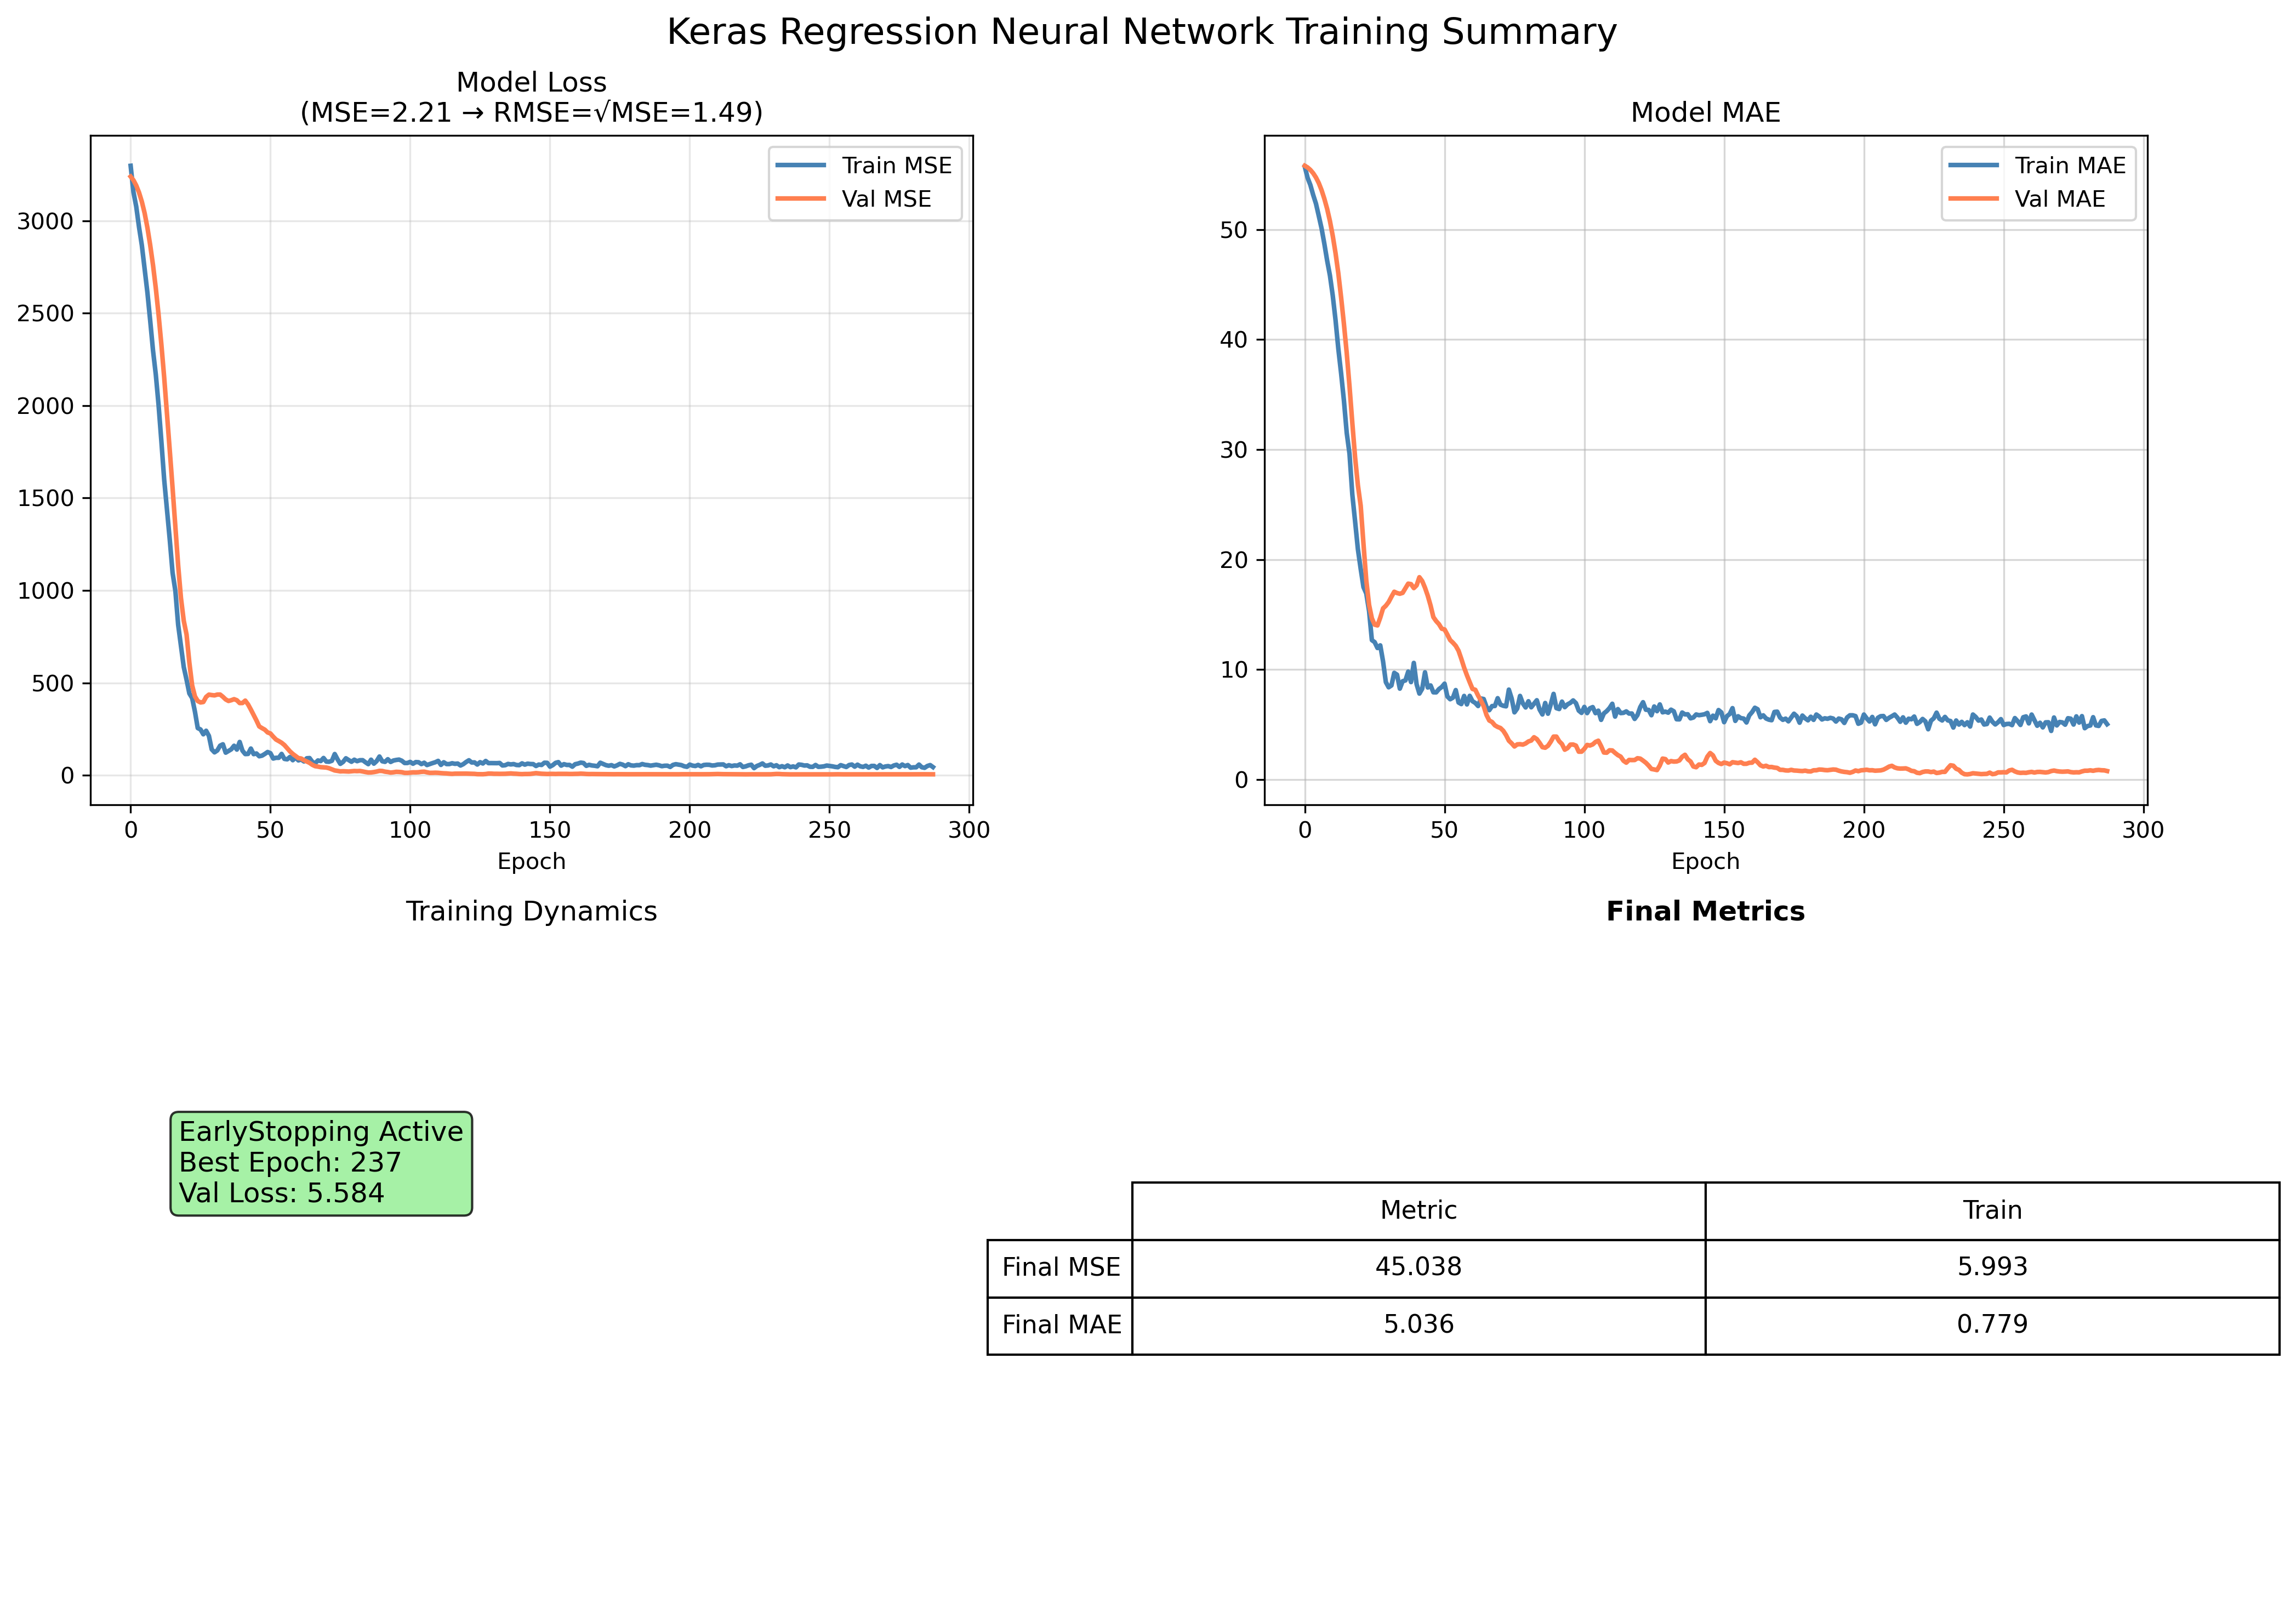

In [24]:
from IPython.display import Image
Image(filename='keras_training_history.png')

In [25]:
# We can redirect the current working directory to the models/ directory and run 1 of our regression models
test_run_models = os.chdir("../../../models")
%pwd

'/home/rc/Academia/capstone/models'

In [26]:
%ls

__init__.py             keras_regression.py  xgboost_base.py
capstone.egg-info/      knn_base.py          xgboost_regression.py
catboost_regression.py  knn_regression.py


Check the example usage in the Python end-to-end builds in index.ipynb. Adjust file paths to load your dataset and run an existing model—ensure data and models are correctly sourced to avoid errors.

Alternatively, you can manually load data and execute the models, verifying paths for portability across environments.

In [27]:
# Example usage in Jupyter Notebooks (usage may vary by programming interface)
!python keras_regression.py --data ../data/Key_indicator_districtwise.csv \
--id-cols State_Name State_District_Name --target Infant_Mortality_Rate_Imr_Total_Person \
--correlation 72 --test-size 0.24 --outdir ../notebooks/artifacts/keras

Keras Regression Deep Learning Neural Network

📈 Raw Dataset Summary
📊 Dataset Shape: (284, 644)
🎯 Target Column: 'Infant_Mortality_Rate_Imr_Total_Person'
🔍 Total Missing Null/NaN Values: 9,297 (5.08%)
/home/rc/Academia/capstone/.pixi/envs/default/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['Total_Fertility_Rate_Rural' 'Total_Fertility_Rate_Urban']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/rc/Academia/capstone/.pixi/envs/default/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['Total_Fertility_Rate_Rural' 'Total_Fertility_Rate_Urban']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/rc/Academia/capstone/.pixi/envs/default/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountere

The Keras deep learning model should generate an artifacts directory with a general overview, results, and its performance metrics

---